# Project: Loan Acceptance Prediction

**Overview:** Predict loan acceptance with a supervised classification workflow.

**Task:** Binary classification
**Dataset:** Loan acceptance dataset (see notebook for source).


## Problem Understanding and Dataset Description
1. Understanding the Problem

I will explore a loan dataset and go through the steps of the data science lifecycle and build a machine learning algorithm to predict a person’s loan will be accepted or rejected based on his/her features.

The target variable to be predicted takes 2 values: **Y** (approved) or **N** (rejected). This is a supervised machine learning task: *Binary Classification*.

2. Dataset Description

The dataset variables include:

*   Loan_ID: data set unique ID
*   Gender: individual gender
*   Married: individual marital status
*   Dependents: number of dependents
*   Education: individual education status
*   Self_Employed: individual employment status
*   ApplicantIncome: individual income
*   CoapplicantIncome: individual Co Applicant income
*   LoanAmount: Loan amount in thousands
*   Loan_Amount_Term: term of loan in months
*   Credit_History: credit history meets guidelines
*   Property_Area: Urban/ Semi Urban/ Rural
*   Loan_Status: loan approved (Y/N) - TARGET

The dataset contains a mixture of categorical features (eg: Gender, Married, Education, Self_Employed, Property Area) and numerical features (eg: ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History). Handling mixed data types requires appropriate preproccessing such as encoding for categorical fields and scaling for numeric features.

3. Insights and Assumptions

*   Assumption 1: Higher total income compared to loan amount will increase approval probability.
*   Assumption 2: Applications with Positive Credit History are more likely to be approved for loans.
*   Assumption 3: Family stability features, such as marital status, number of dependents, and property location, could have influence on the outcomes.


## Imports and Setup

In [2]:
#import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
train_url = "https://drive.google.com/uc?id=1kOZgprQhpJ0EQkCU-WBhE5Y8toW8bHnk"
test_url = "https://drive.google.com/uc?id=1r4AyrYG2D-0DFt0fpOW-QCK6K9YrL6EP"

#Load the data
train_df = pd.read_csv(train_url)
test_df = pd.read_csv(test_url)

##Exploratory Data Analysis (EDA)
The goal is to explore the dataset understand the distributions, relationships and discover any patterns.

### Initial Inspection

How many rows and columns?

In [4]:
train_shape = train_df.shape
test_shape = test_df.shape

print(f"In the Train dataset there are {train_shape[0]} rows and {train_shape[1]} columns.")
print(f"In the Test dataset there are {test_shape[0]} rows and {test_shape[1]} columns.")

In the Train dataset there are 513 rows and 13 columns.
In the Test dataset there are 101 rows and 13 columns.


Initial inspection include checking for missing values and data types using the info() function. For numerical features will we use the describe() function to check the mean, standard deviation, maximum, and minimum

In [5]:
print(train_df.info())
print(train_df.describe())
print("\nMissing Values:")
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            513 non-null    object 
 1   Gender             503 non-null    object 
 2   Married            510 non-null    object 
 3   Dependents         501 non-null    object 
 4   Education          513 non-null    object 
 5   Self_Employed      486 non-null    object 
 6   ApplicantIncome    513 non-null    int64  
 7   CoapplicantIncome  513 non-null    float64
 8   LoanAmount         495 non-null    float64
 9   Loan_Amount_Term   499 non-null    float64
 10  Credit_History     470 non-null    float64
 11  Property_Area      513 non-null    object 
 12  Loan_Status        513 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 52.2+ KB
None
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       513.000000         5

###Visualizations

#### Loan Appoval Status Distribution

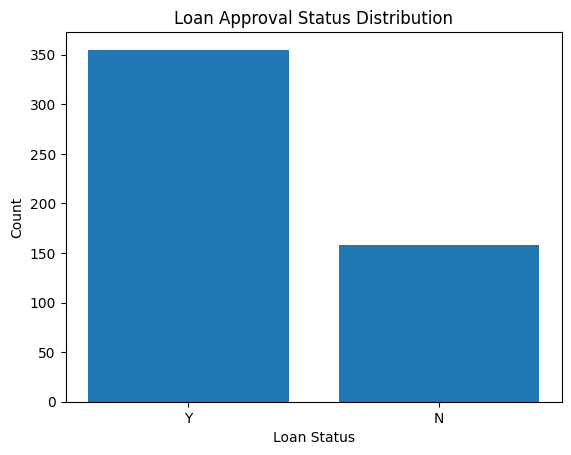

In [6]:
status_counts = train_df['Loan_Status'].value_counts()

plt.figure()
plt.bar(status_counts.index, status_counts.values)
plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

The bar chart shows that more loans are approved than rejected. This means that the dataset distribution is imbalanced. The model could achieve high accuracy by predicting "Approved" most of the time but may perform poorly on rejected cases which are more important in most cases.

#### Loan Approval by Credit History

Credit_History
1.0    316
0.0      6
Name: count, dtype: int64
Credit_History
1.0    82
0.0    66
Name: count, dtype: int64


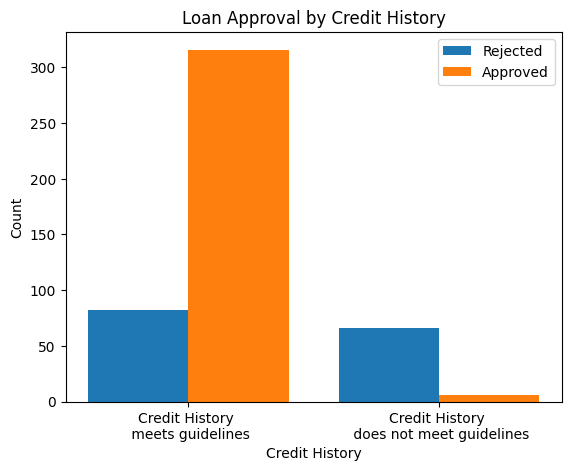

In [7]:
credit_approved = train_df[train_df['Loan_Status'] == 'Y']['Credit_History'].value_counts() #count the number of cases with good credit history
credit_rejected = train_df[train_df['Loan_Status'] == 'N']['Credit_History'].value_counts() #count the number of cases with bad credit history
print(credit_approved)
print(credit_rejected)

labels = ['Credit History \n meets guidelines', 'Credit History \n does not meet guidelines'] #x-axis labels
x = np.arange(len(labels)) #positions for bars

plt.figure()
plt.bar(x - 0.2, credit_rejected, width=0.4, label='Rejected')
plt.bar(x + 0.2, credit_approved, width=0.4, label='Approved')
plt.xticks(x, labels)
plt.title('Loan Approval by Credit History')
plt.xlabel('Credit History')
plt.ylabel('Count')
plt.legend()
plt.show()

The bar chart confirms that applicants with a credit history that meets the guidelines are far more likely to be approved for loans.

#### Distribution of Total Income

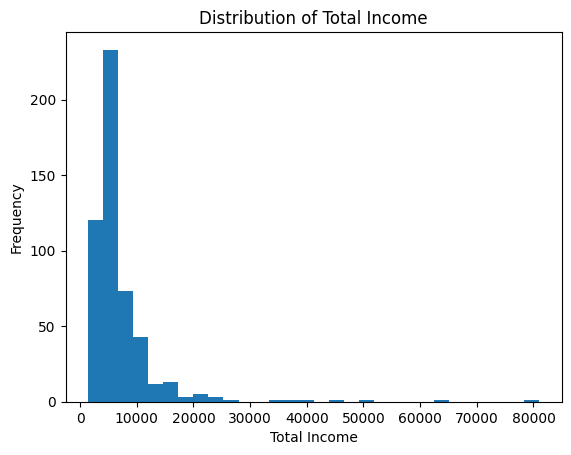

In [8]:
train_df['Total_Income'] = train_df['ApplicantIncome'] + train_df['CoapplicantIncome']

plt.figure()
plt.hist(train_df['Total_Income'], bins=30)
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

The distribution is right-skewed, most of the income of applicants concentrate on the lower end. This shows the need to do feature scaling or transformation.

#### Loan Amount vs Loan Status

/tmp/ipython-input-3166867863.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([approved.dropna(), rejected.dropna()], labels=['Approved', 'Rejected'])


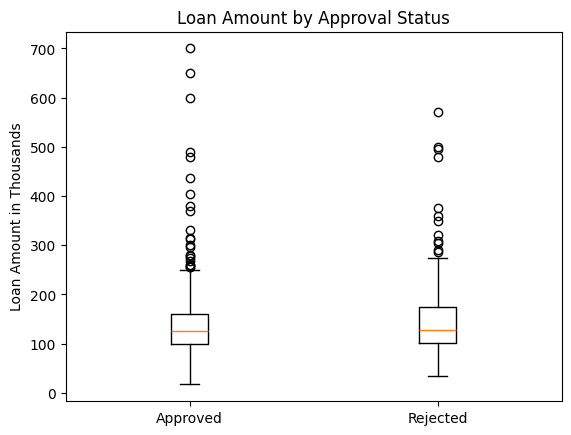

In [9]:
approved = train_df[train_df['Loan_Status'] == 'Y']['LoanAmount']
rejected = train_df[train_df['Loan_Status'] == 'N']['LoanAmount']

plt.figure()
plt.boxplot([approved.dropna(), rejected.dropna()], labels=['Approved', 'Rejected'])
plt.title('Loan Amount by Approval Status')
plt.ylabel('Loan Amount in Thousands')
plt.show()

There is no significant difference in the loan amount between approved and rejected loans, as the box plot shows the median and overall distributions are similar.

Approval may be influenced more by other factors (like income or employment) than the loan amount itself.

#### Property Area vs Loan Status

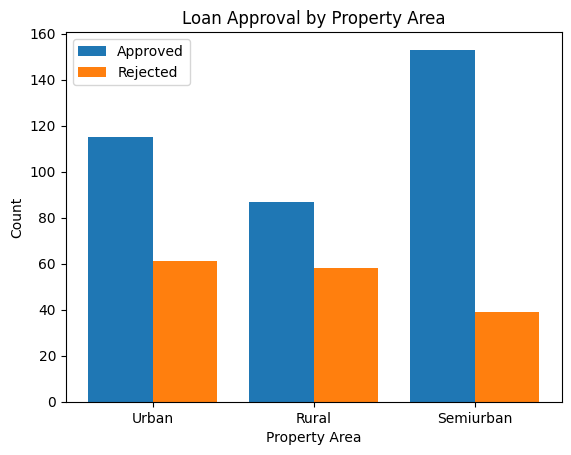

In [10]:
property_area = train_df['Property_Area'].unique()

approved_counts = train_df[train_df['Loan_Status'] == 'Y']['Property_Area'].value_counts()
rejected_counts = train_df[train_df['Loan_Status'] == 'N']['Property_Area'].value_counts()

x = np.arange(len(property_area))

plt.figure()
plt.bar(x - 0.2, approved_counts[property_area], width=0.4, label='Approved')
plt.bar(x + 0.2, rejected_counts[property_area], width=0.4, label='Rejected')
plt.xticks(x, property_area)
plt.title('Loan Approval by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Count')
plt.legend()
plt.show()

The bar chart shows that semiurban area has has the highest number of approvals and the lowest number of rejections. Urban areas have more loan approvals than rural area but more rejections than semiurban areas.

## Data Preperation and Feature Engineering

### Handling Missing Values

Numerical features in the dataset are skewed and contain outliers (as shown in the visualizations above for the Total_Income and Loan_Amount). The mean will be misleading as it will be pulled up or down by extreme values. Instead to have a better representation of the distribution, the median is chosen to be more realistic.

In the case of categorical features, to avoid unreliastic new labels, mode is used to replace missing values with most frequent valid category.

In [11]:
# for training data

for feature in train_df.select_dtypes(include='object').columns:
    train_df[feature].fillna(train_df[feature].mode()[0], inplace=True) #fill missing categorical features with mode

for feature in train_df.select_dtypes(include='number').columns:
    train_df[feature].fillna(train_df[feature].median(), inplace=True) #fill missing numerical features with median

# for test data

for feature in test_df.select_dtypes(include='object').columns:
    test_df[feature].fillna(test_df[feature].mode()[0], inplace=True) #fill missing categorical features with mode

for feature in test_df.select_dtypes(include='number').columns:
    test_df[feature].fillna(test_df[feature].median(), inplace=True) #fill missing numerical features with median

print("\nMissing Values:")
print(train_df.isnull().sum())


Missing Values:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
Total_Income         0
dtype: int64


/tmp/ipython-input-4139635224.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[feature].fillna(train_df[feature].mode()[0], inplace=True) #fill missing categorical features with mode
/tmp/ipython-input-4139635224.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

### Feature Engineering

To represent the financial risk in a better way, new features are created to improve model performance:
*   Total Income
*   Monthly Installments
*   Income to Loan Ratio

In [12]:
# for training data

train_df['Total_Income'] = (
    train_df['ApplicantIncome'] + train_df['CoapplicantIncome']
)

train_df['Monthly_Installments'] = (
    train_df['LoanAmount'] / train_df['Loan_Amount_Term']
)

train_df['Income_Loan_Ratio'] = (
    train_df['Total_Income'] / train_df['LoanAmount']
)

# for testing data

test_df['Total_Income'] = (
    test_df['ApplicantIncome'] + test_df['CoapplicantIncome']
)

test_df['Monthly_Installments'] = (
    test_df['LoanAmount'] / test_df['Loan_Amount_Term']
)

test_df['Income_Loan_Ratio'] = (
    test_df['Total_Income'] / test_df['LoanAmount']
)

Next, These features were dropped for the following reasons:

*   Loan_ID: this is an identifier and not a predictor.
*   ApplicantIncome, CoapplicantIncome: Redundant after creating Total_Income.

In [13]:
columns_to_drop = ['Loan_ID','ApplicantIncome', 'CoapplicantIncome']

train_df.drop(columns=columns_to_drop, inplace=True)
test_df.drop(columns=columns_to_drop, inplace=True)

train_df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,Monthly_Installments,Income_Loan_Ratio
0,Male,No,0,Graduate,No,127.0,360.0,1.0,Urban,Y,5849.0,0.352778,46.055118
1,Male,Yes,1,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0,0.355556,47.585938
2,Male,Yes,0,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0,0.183333,45.454545
3,Male,Yes,0,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0,0.333333,41.175000
4,Male,No,0,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0,0.391667,42.553191


### Encoding Categorical Features

Machine learning models require numerical inputs. Categorical features such as Gender, Married and Property_Area must be converted to numeric form.

Two types of encoding were used: label encoding for binary features and one-hot encoding for features with more than two categories.

In [14]:
train_df['Loan_Status'] = train_df['Loan_Status'].map({'Y': 1, 'N': 0}) #encoding the target variable
test_df['Loan_Status'] = test_df['Loan_Status'].map({'Y': 1, 'N': 0})

categorical_cols = train_df.select_dtypes(include='object').columns #find the categorical columns
print(categorical_cols)
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True) #apply one-hot encoding
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

train_df.head()

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_Income,Monthly_Installments,Income_Loan_Ratio,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,127.0,360.0,1.0,1,5849.0,0.352778,46.055118,True,False,False,False,False,False,False,False,True
1,128.0,360.0,1.0,0,6091.0,0.355556,47.585938,True,True,True,False,False,False,False,False,False
2,66.0,360.0,1.0,1,3000.0,0.183333,45.454545,True,True,False,False,False,False,True,False,True
3,120.0,360.0,1.0,1,4941.0,0.333333,41.175000,True,True,False,False,False,True,False,False,True
4,141.0,360.0,1.0,1,6000.0,0.391667,42.553191,True,False,False,False,False,False,False,False,True


###Feature Scaling

Feature scaling is important because it ensures that all numerical features contribute appropriately to the model. The dataset features are on very different scales. Without scaling, large magnitude features will dominate the model and low magnitude features are ignored.

In [15]:
X_train = train_df.drop('Loan_Status', axis=1)
y_train = train_df['Loan_Status']
X_test = test_df.drop('Loan_Status', axis=1)
y_test = test_df['Loan_Status']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

## Model Building

Logistic Regression was selected because it is suitable for binary classification problems such as this challenge. The model was trained on the preprocessed dataset.

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [19]:
y_pred = model.predict(X_test_scaled)

print("Accuracy: \n", accuracy_score(y_test, y_pred))
print("Classification Report: \n", classification_report(y_test, y_pred))
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Accuracy: 
 0.8118811881188119
Classification Report: 
               precision    recall  f1-score   support

           0       0.94      0.47      0.63        34
           1       0.79      0.99      0.87        67

    accuracy                           0.81       101
   macro avg       0.86      0.73      0.75       101
weighted avg       0.84      0.81      0.79       101

Confusion Matrix: 
 [[16 18]
 [ 1 66]]


The logistic regression model achieves an accuracy of **81.2%**.
This is **good overall performance** on a relatively small and imbalanced dataset.

**Confusion Matrix Interpretation:**

Correctly rejected loans (*True Negatives*) = 16

Incorrectly approved loans (*False Positives*) = 18

Incorrectly rejected loans (*False Negative*) = 1

Correctly approved loans (*True Positives*) = 66

**Performance Metrics:**

Approved Loans (Class 1)

*Recall* is 99% indicating that the model almost never misses approved loans.
*Precision* is 79% indicating that the model approved 21% loans that should have been rejected.

Rejected Loans (Class 0)

*Recall* is 47% indicating the model approved more than half the loans the should have been rejected.
*Precision* is 94% indicating that when the model rejects a loan it is usually correct.



## Feature Importance Using Coefficient Analysis

In [20]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance.sort_values(by='Absolute_Coefficient', ascending=False).head(10) #sorting the top 10 features

,Feature,Coefficient,Absolute_Coefficient
2,Credit_History,1.323326,1.323326
13,Property_Area_Semiurban,0.534917,0.534917
1,Loan_Amount_Term,-0.341379,0.341379
8,Dependents_1,-0.239226,0.239226
7,Married_Yes,0.198597,0.198597
11,Education_Not Graduate,-0.186340,0.186340
5,Income_Loan_Ratio,0.180426,0.180426
9,Dependents_2,0.141865,0.141865
4,Monthly_Installments,-0.102329,0.102329
14,Property_Area_Urban,0.090977,0.090977


Feature Importance was determined using the absolute values of the logistic regression coefficients. Since all the features are standarized, the magnitude of each coefficient indicates the relative effect on the prediction outcome. Credit History is the most influential feature by far. A good credit history strongly increases the probability of loan approval. Property location and loan term have strong influence as well. People living in semiurban areas are more likely to be approved. Longer loan terms reduce approval chances. Other income based or family related features have moderate influence on the model.

## Conclusion
In this challenge I successfully explored the data science lifecycle and applied it to predicting loan approval outcomes. I performed data exploration, preprocessing, feature engineering, and built a logistic regression model to understand key factors influencing loan decisions. The results confirmed that credit history is the most important predictor, while income-related and other features have a moderate impact.
This challenge helped me understand the importance of proper data preparation, feature scaling, and model evaluation beyond accuracy (sometimes it may be misleading). Overall, it strengthened my ability to build interpretable models and analyze results in a financial context.